In [2]:
from mdcrow import MDCrow
from langchain.callbacks import get_openai_callback
from datetime import datetime
import os 
import traceback

In [2]:
import sys
parent_dir = os.path.abspath(os.path.join(os.getcwd(), '../'))
sys.path.append(parent_dir)
from robustness_prompts import get_prompt # noqa: E402

prompt_10_natural = get_prompt("natural", 10)

prompt_10_natural

'Simulate 1LYZ for 1ps at 300 K and for 1ps at 400K. Report the secondary structure assignments of the downloaded PDB structure and any known binding or active sites. Compute RMSD and radius of gyration of both simulations. Compute SASA for the 300K simulation.'

In [3]:
llm_model = "together/meta-llama/Meta-Llama-3.1-70B-Instruct-Turbo"
tools = "all"

In [4]:
agent = MDCrow(
    agent_type="Structured", 
    model=llm_model, 
    top_k_tools=tools, 
    use_memory=False,
    streaming=False,
    verbose=True,
)
with get_openai_callback() as cb:
    chat_start = datetime.now()
    try:
        response = agent.run(prompt_10_natural, callbacks=[cb])
        print(response)
    except Exception as e:
        exc_type, exc_value, exc_traceback = sys.exc_info()
        print(f'{type(e).__name__}:{e}')
        print("".join(traceback.format_exception(exc_type, exc_value, exc_traceback)))
    chat_end = datetime.now()
    total_runtime = (chat_end - chat_start).total_seconds()
    print(cb)
    print(f"Total runtime: {total_runtime:.2f}s")



> Entering new AgentExecutor chain...


Thought: To solve this problem, we need to first download the PDB structure of 1LYZ, then simulate it at 300 K and 400 K for 1 ps each. After that, we can compute the secondary structure assignments, RMSD, radius of gyration, and SASA for the simulations.

Action:
```
{
  "action": "PDBFileDownloader",
  "action_input": "1LYZ"
}
```
PDB file found with this ID: 1LYZ

Observation: Succeeded. Downloaded the PDB file:1LYZ_215104
Thought:

Thought: Now that we have the PDB file, we can simulate it at 300 K and 400 K for 1 ps each. We will use the SetUpandRunFunction tool to set up and run the simulations.

Action:
```
{
  "action": "SetUpandRunFunction",
  "action_input": {
    "pdb_id": "1LYZ_215104",
    "forcefield_files": ["amber99sbildn.xml", "tip3p.xml"],
    "save": true,
    "system_params": {
      "nonbondedMethod": "PME",
      "nonbondedCutoff": "1.0 * nanometers",
      "ewaldErrorTolerance": 0.0005,
      "constraints": "HBonds",
      "rigidWater": true,
      "constraintTolerance": 0.00001,
      "solvate": true
    },
    "integrator_params": {
      "integrator_type": "LangevinMiddle",
      "Temperature": "300 * kelvin",
      "Friction": "1.0 / picoseconds",
      "Timestep": "0.002 * picoseconds",
      "Pressure": "1.0 * bar"
    },
    "simulation_params": {
      "Ensemble": "NPT",
      "Number of Steps": 500,
      "record_interval_steps": 100,
      "record_params": ["step", "potentialEnergy", 

About to create system...
Attempts at creating system: 0/3
Error adding solvent ValueError – No template found for residue 1 (LYS).  The set of atoms is similar to HID, but it is missing 8 atoms.  For more information, see https://github.com/openmm/openmm/wiki/Frequently-Asked-Questions#template
Residue code: LYS
Residue code not in solvent list. Adding forcefield                         not supported.

Observation: Failed. No template found for residue 1 (LYS).  The set of atoms is similar to HID, but it is missing 8 atoms.  For more information, see https://github.com/openmm/openmm/wiki/Frequently-Asked-Questions#templateThis were the inputs {'pdb_id': '1LYZ_215104', 'forcefield_files': ['amber99sbildn.xml', 'tip3p.xml'], 'save': True, 'system_params': {'nonbondedMethod': 'PME', 'nonbondedCutoff': '1.0 * nanometers', 'ewaldErrorTolerance': 0.0005, 'constraints': 'HBonds', 'rigidWater': True, 'constraintTolerance': 1e-05, 'solvate': True}, 'integrator_params': {'integrator_type': 'Lan

Thought: The SetUpandRunFunction tool failed to set up and run the simulation because it couldn't find a template for residue 1 (LYS). We need to clean the PDB file to replace non-standard residues with standard ones. We will use the CleaningToolFunction tool to clean the PDB file.

Action:
```
{
  "action": "CleaningToolFunction",
  "action_input": {
    "pdb_id": "1LYZ_215104",
    "replace_nonstandard_residues": true,
    "add_missing_atoms": true,
    "remove_heterogens": true,
    "remove_water": true,
    "add_hydrogens": true,
    "add_hydrogens_ph": 7.0
  }
}
```file path: /gpfs/fs2/scratch/qcampbe2/repos/MDCrow/ckpt/ckpt_29/pdb/1LYZ_raw_20251222_215104.pdb


...

Thought: Now that we have computed the secondary structure assignments, RMSD, radius of gyration, and SASA for the simulations, we can report the results. We will also retrieve the known binding or active sites for the protein.

Action:
```
{
  "action": "GetBindingSites",
  "action_input": {
    "query": "1LYZ",
    "primary_accession": "P00722"
  }
}
```


The primary accession number provided does not match any entry in the data, using the first entry instead.

Observation: []
Thought:

Thought: Now that we have computed the secondary structure assignments, RMSD, radius of gyration, and SASA for the simulations, we can report the results. We will also retrieve the known active sites for the protein.

Action:
```
{
  "action": "GetActiveSites",
  "action_input": {
    "query": "1LYZ",
    "primary_accession": "P00722"
  }
}
```

The primary accession number provided does not match any entry in the data, using the first entry instead.

Observation: [{'start': 53, 'start_modifier': 'EXACT', 'end': 53, 'end_modifier': 'EXACT', 'description': '', 'evidences': [{'evidenceCode': 'ECO:0000255', 'source': 'PROSITE-ProRule', 'id': 'PRU00680'}]}, {'start': 71, 'start_modifier': 'EXACT', 'end': 71, 'end_modifier': 'EXACT', 'description': '', 'evidences': [{'evidenceCode': 'ECO:0000255', 'source': 'PROSITE-ProRule', 'id': 'PRU00680'}]}]
Thought:

> Finished chain.
({'input': '\n    You are an expert molecular dynamics scientist, and\n    your task is to respond to the question or\n    solve the problem to the best of your ability using\n    the provided tools.\n\n    You can only respond with a single complete\n    \'Thought, Action, Action Input\' format\n    OR a single \'Final Answer\' format.\n\n    Complete format:\n    Thought: (reflect on your progress and decide what to do next)\n    Action:\n    ```\n    {\n     

<Figure size 640x480 with 0 Axes>

In [4]:
registry = agent.path_registry
print(registry.list_path_names_and_descriptions().replace(",", "\n"))

Files found in registry: 1LYZ_215104: PDB file downloaded from RSCB
 PDBFile ID: 1LYZ_215104
 1LYZ_215110: Cleaned File:  Removed Heterogens
 and Water Removed.  Replaced Nonstandard Residues. Added Hydrogens at pH 7.0. Missing Atoms added and nonstandard residues replaced. 
 top_sim0_215112: Initial positions for simulation sim0_215112
 sim0_215112: Basic Simulation of Protein 1LYZ_215110
 rec0_215118: Simulation trajectory for protein 1LYZ_215110 and simulation sim0_215112
 rec1_215118: Simulation state log for protein 1LYZ_215110 and simulation sim0_215112
 rec2_215118: Simulation pdb frames for protein 1LYZ_215110 and simulation sim0_215112
 top_sim0_220153: Initial positions for simulation sim0_220153
 sim0_220153: Basic Simulation of Protein 1LYZ_215110
 rec0_220200: Simulation trajectory for protein 1LYZ_215110 and simulation sim0_220153
 rec1_220200: Simulation state log for protein 1LYZ_215110 and simulation sim0_220153
 rec2_220200: Simulation pdb frames for protein 1LYZ_2151

In [5]:
# make sure pdb was downloaded
assert os.path.exists(registry.get_mapped_path("1LYZ_215104"))

In [6]:
# make sure dssp was computed correctly
from mdcrow.tools.base_tools import ComputeDSSP

dssp = ComputeDSSP(registry)
dssp._run(traj_file= "1LYZ_215104", target_frames="first")

"{'residues in helix': 50, 'residues in strand': 14, 'residues in coil': 65, 'residues not assigned, not a protein residue': 101}"

In [9]:
# make sure the sites were found
from mdcrow.tools.base_tools import GetAllKnownSites

get_all_known_sites = GetAllKnownSites()
get_all_known_sites._run(query="1LYZ", primary_accession="")

"Active Sites: [{'start': 53, 'start_modifier': 'EXACT', 'end': 53, 'end_modifier': 'EXACT', 'description': '', 'evidences': [{'evidenceCode': 'ECO:0000255', 'source': 'PROSITE-ProRule', 'id': 'PRU00680'}]}, {'start': 71, 'start_modifier': 'EXACT', 'end': 71, 'end_modifier': 'EXACT', 'description': '', 'evidences': [{'evidenceCode': 'ECO:0000255', 'source': 'PROSITE-ProRule', 'id': 'PRU00680'}]}]\nNo known binding sites.\nNo other relevant sites."

In [7]:
# make sure trajectory and topology exist
traj_path_1 = registry.get_mapped_path("rec0_215118")
top_path_1 = registry.get_mapped_path("top_sim0_215112")

assert os.path.exists(traj_path_1)
assert os.path.exists(top_path_1)

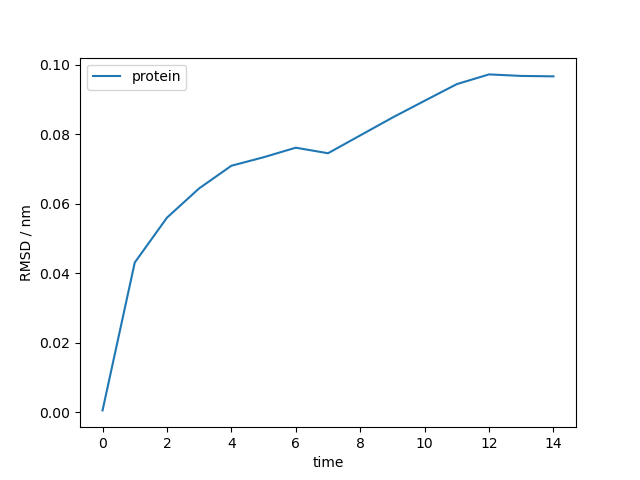

In [8]:
# make sure rmsd plot was generated
from IPython.display import Image
Image(filename=registry.get_mapped_path('fig0_221258'))

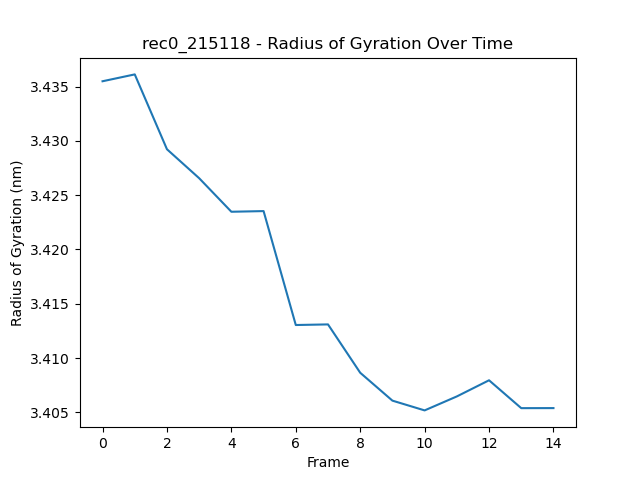

In [10]:
# make sure rgy plot was generated
from IPython.display import Image
Image(filename=registry.get_mapped_path('fig0_221304'))

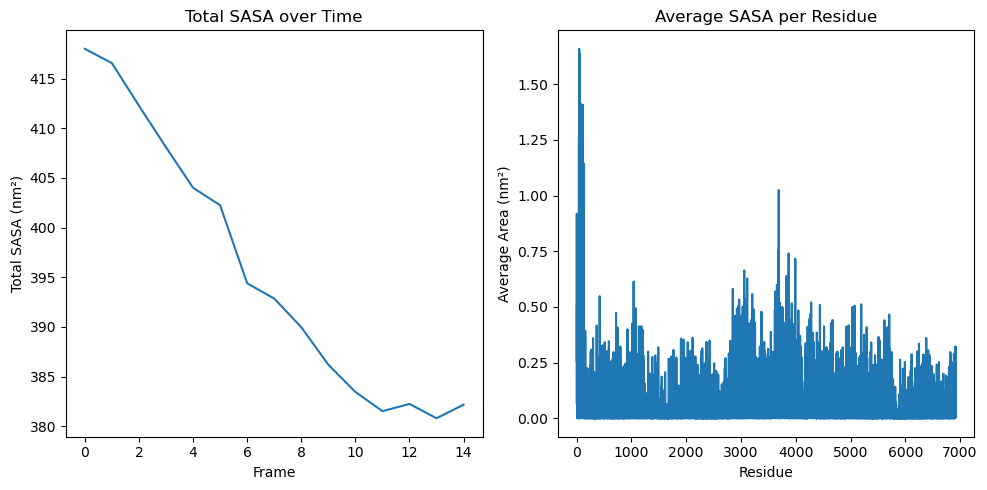

In [13]:
# make sure sasa plot was generated
from IPython.display import Image
Image(filename=registry.get_mapped_path('fig0_221425'))

In [15]:
# make sure trajectory and topology exist (sim2)
traj_path_2 = registry.get_mapped_path("rec0_220200")
top_path_2 = registry.get_mapped_path("top_sim0_220153")

assert os.path.exists(traj_path_2)
assert os.path.exists(top_path_2)

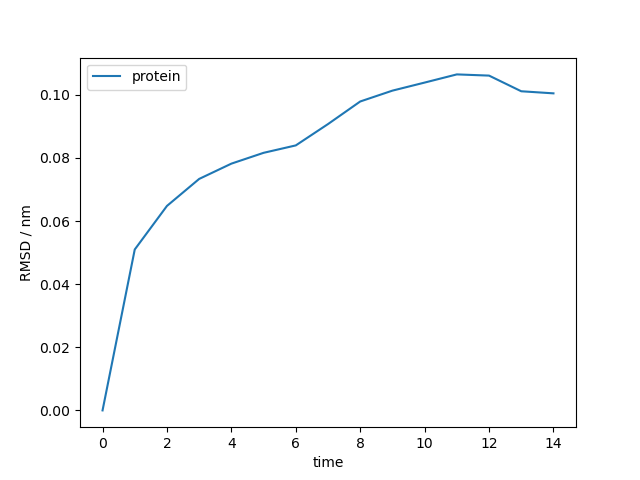

In [9]:
# make sure rmsd plot was generated (sim2)
from IPython.display import Image
Image(filename=registry.get_mapped_path('fig0_221301'))

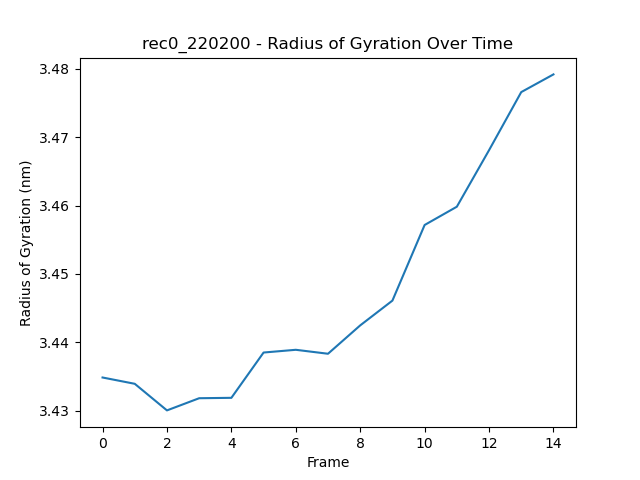

In [12]:
# make sure rgy plot was generated (sim2)
from IPython.display import Image
Image(filename=registry.get_mapped_path('fig0_221307'))

In [16]:
#verify the total cost
def calculate_llm_cost(input_tokens, output_tokens, model):
    if model == 'meta-llama/Meta-Llama-3.1-70B-Instruct-Turbo':
        model = "llama-v3p1-70b-instruct"
    elif model == 'meta-llama/Meta-Llama-3.1-405B-Instruct-Turbo':
        model = "llama-v3p1-405b-instruct"
    pricing_2024 = {
        "gpt-4-1106-preview": {"input": 10/1e6, "output": 30/1e6},
        "gpt-3.5-turbo-0125": {"input": 0.5/1e6, "output": 1.5/1e6},
        "gpt-4-turbo-2024-04-09": {"input": 10/1e6, "output": 30/1e6},
        "gpt-4o-2024-08-06": {"input": 5/1e6, "output": 15/1e6},
        "llama-v3p1-70b-instruct": {"input": 0.9/1e6, "output": 0.9/1e6},
        "llama-v3p1-405b-instruct": {"input": 3/1e6, "output": 3/1e6},
        "claude-3-opus": {"input": 15/1e6, "output": 75/1e6},
        "claude-3.5-sonnet": {"input": 3/1e6, "output": 15/1e6},
    }
    pricing_2025 = {
        "gpt-4-1106-preview": {"input": 10/1e6, "output": 30/1e6},
        "gpt-3.5-turbo-0125": {"input": 0.5/1e6, "output": 1.5/1e6},
        "gpt-4-turbo-2024-04-09": {"input": 10/1e6, "output": 30/1e6},
        "gpt-4o-2024-08-06": {"input": 2.5/1e6, "output": 10/1e6},
        "llama-v3p1-70b-instruct": {"input": 0.9/1e6, "output": 0.9/1e6},
        "llama-v3p1-405b-instruct": {"input": 3/1e6, "output": 3/1e6},
    }
    
    prices = pricing_2025[model]
    cost = (input_tokens * prices["input"]) + (output_tokens * prices["output"])
    return round(cost, 6)

llm_cost = calculate_llm_cost(144398, 2383, 'meta-llama/Meta-Llama-3.1-70B-Instruct-Turbo')
print('Input tokens:',144398)
print('Output tokens:',2383)
print('LLM costs: $',llm_cost)

Input tokens: 144398
Output tokens: 2383
LLM costs: $ 0.132103
